``ReliabilityModelPlot().ood_hist()`` shows the out-of-distribution score distribution
from ``ReliabilityModel.predict()``, with the in-domain boundary drawn at ``1.0``.

In [1]:
import aaanalysis as aa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
aa.options["verbose"] = False
aa.plot_settings()
X, labels = make_classification(n_samples=160, n_features=10, n_informative=6, random_state=42)
X_train, labels_train = X[:120], labels[:120]
# include one clearly out-of-distribution sample so the trust status is visible
X_new = np.vstack([X[120:], (X_train[labels_train == 1][0] + 20.0)[None, :]])
rm = aa.ReliabilityModel(random_state=42).fit(X=X_train, labels=labels_train)
df_rel = rm.predict(X=X_new)
df_eval = rm.eval(X=X[120:], labels=labels[120:])

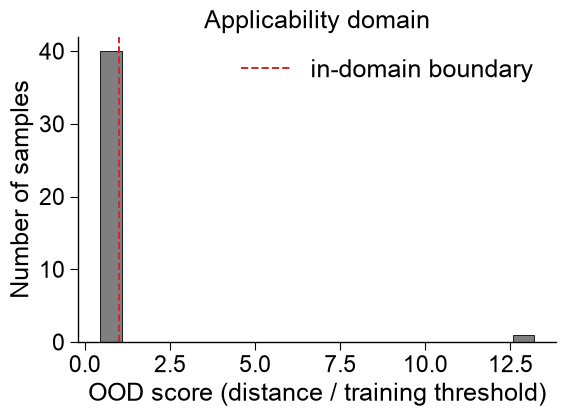

In [2]:
aa.ReliabilityModelPlot().ood_hist(df_rel=df_rel, figsize=(6, 4.5), bins=20,
                                   color="tab:gray", title="Applicability domain", ax=None)
plt.tight_layout()
plt.show()